In [2]:
# Age × Sex N3 Sleep Analysis
# Research Question: How do age and sex influence N3 sleep, and do they interact?

import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Imports successful")

✅ Imports successful


In [ ]:
# Load 50 subjects for better statistical power
subjects = list(range(50))
data_list = []

print("Loading 50 subjects...")
print("⏱️  This will take 30-45 minutes (~2.5 GB download)")
print("=" * 60)

for subj in subjects:
    try:
        files = mne.datasets.sleep_physionet.age.fetch_data(
            subjects=[subj], 
            recording=[1]
        )
        
        raw = mne.io.read_raw_edf(files[0][0], preload=True, verbose=False)
        annot = mne.read_annotations(files[0][1])
        raw.set_annotations(annot)
        
        data_list.append({
            'subject': subj,
            'raw': raw,
            'annotations': annot
        })
        
        # Progress updates after every subject
        print(f"✅ Progress: {subj + 1}/50 subjects loaded")
        
    except Exception as e:
        print(f"❌ Subject {subj} failed: {e}")

print("=" * 60)
print(f"✅ Total loaded: {len(data_list)} subjects")

In [4]:
# Extract N3 sleep percentages for all subjects
results = []

for data in data_list:
    subj = data['subject']
    annot = data['annotations']
    raw = data['raw']
    
    # Total recording duration
    total_duration = raw.times[-1]
    
    # Find all N3 sleep
    n3_duration = 0
    for desc, duration in zip(annot.description, annot.duration):
        if 'Sleep stage 3' in desc or 'Sleep stage N3' in desc:
            n3_duration += duration
    
    # Calculate percentage
    n3_percent = (n3_duration / total_duration) * 100
    
    results.append({
        'subject': subj,
        'n3_duration_sec': n3_duration,
        'total_duration_sec': total_duration,
        'n3_percent': n3_percent
    })

df = pd.DataFrame(results)
print(f"✅ Extracted N3 data for {len(df)} subjects")
df.head()

✅ Extracted N3 data for 48 subjects


,subject,n3_duration_sec,total_duration_sec,n3_percent
0,0,3030.0,79499.99,3.811321
1,1,2880.0,84059.99,3.426125
2,2,2190.0,84119.99,2.603424
3,3,1680.0,84599.99,1.985816
4,4,1590.0,77099.99,2.062257


In [10]:
# Real ages and sex from Sleep-EDF database
# Source: SC-subjects.xls from PhysioNet Sleep-EDF v1.0.0
# https://physionet.org/content/sleep-edfx/1.0.0/

age_sex_mapping = {
    0: (33, 'F'), 1: (33, 'F'), 2: (26, 'F'), 3: (26, 'F'), 4: (34, 'F'),
    5: (28, 'F'), 6: (31, 'F'), 7: (30, 'F'), 8: (25, 'F'), 9: (25, 'F'),
    10: (26, 'M'), 11: (26, 'M'), 12: (26, 'M'), 13: (27, 'M'), 14: (27, 'M'),
    15: (31, 'M'), 16: (32, 'M'), 17: (31, 'M'), 18: (28, 'M'), 19: (28, 'M'),
    20: (51, 'F'), 21: (51, 'F'), 22: (56, 'F'), 23: (50, 'F'), 24: (54, 'F'),
    25: (56, 'F'), 26: (51, 'F'), 27: (54, 'F'), 28: (56, 'F'), 29: (51, 'F'),
    30: (50, 'M'), 31: (54, 'M'), 32: (57, 'M'), 33: (60, 'M'), 34: (54, 'M'),
    35: (57, 'M'), 37: (52, 'M'), 38: (51, 'M'),
    40: (67, 'F'), 41: (66, 'F'), 42: (69, 'F'), 43: (73, 'F'), 44: (74, 'F'),
    45: (66, 'F'), 46: (66, 'F'), 47: (73, 'F'), 48: (67, 'F'), 49: (67, 'F'),
}

# Add age and sex to dataframe
df['age'] = df['subject'].map(lambda x: age_sex_mapping.get(x, (None, None))[0])
df['sex'] = df['subject'].map(lambda x: age_sex_mapping.get(x, (None, None))[1])

# Remove any subjects without age/sex data
df = df.dropna(subset=['age', 'sex'])

print("✅ Added age and sex data from PhysioNet SC-subjects.xls")
print(f"\nSample size: {len(df)} subjects")
print(f"Males: {(df['sex'] == 'M').sum()}, Females: {(df['sex'] == 'F').sum()}")
print(f"Age range: {df['age'].min():.0f} - {df['age'].max():.0f} years")
print()
df.head(10)

✅ Added age and sex data from PhysioNet SC-subjects.xls

Sample size: 48 subjects
Males: 18, Females: 30
Age range: 25 - 74 years



,subject,n3_duration_sec,total_duration_sec,n3_percent,age,sex,age_group
0,0,3030.0,79499.99,3.811321,33,F,Younger (<50)
1,1,2880.0,84059.99,3.426125,33,F,Younger (<50)
2,2,2190.0,84119.99,2.603424,26,F,Younger (<50)
3,3,1680.0,84599.99,1.985816,26,F,Younger (<50)
4,4,1590.0,77099.99,2.062257,34,F,Older (≥50)
5,5,3480.0,81659.99,4.261573,28,F,Older (≥50)
6,6,1050.0,83099.99,1.263538,31,F,Older (≥50)
7,7,2400.0,84299.99,2.846975,30,F,Older (≥50)
8,8,4740.0,83879.99,5.650931,25,F,Older (≥50)
9,9,2610.0,81959.99,3.184481,25,F,Older (≥50)


In [11]:
# Summary statistics by sex
print("📊 Descriptive Statistics by Sex:")
print("=" * 60)

for sex in ['M', 'F']:
    subset = df[df['sex'] == sex]
    sex_label = 'Males' if sex == 'M' else 'Females'
    print(f"\n{sex_label} (n={len(subset)}):")
    print(f"  Age: {subset['age'].mean():.1f} ± {subset['age'].std():.1f} years")
    print(f"  N3%: {subset['n3_percent'].mean():.2f} ± {subset['n3_percent'].std():.2f}%")

# Summary by age group and sex
df['age_group'] = df['age'].apply(lambda x: 'Younger (<50)' if x < 50 else 'Older (≥50)')

print("\n" + "=" * 60)
print("📊 N3% by Age Group and Sex:")
print("=" * 60)

summary = df.groupby(['age_group', 'sex'])['n3_percent'].agg(['count', 'mean', 'std'])
print(summary)

📊 Descriptive Statistics by Sex:

Males (n=18):
  Age: 39.8 ± 13.7 years
  N3%: 2.40 ± 2.03%

Females (n=30):
  Age: 50.3 ± 16.9 years
  N3%: 2.37 ± 1.38%

📊 N3% by Age Group and Sex:
                   count      mean       std
age_group     sex                           
Older (≥50)   F       20  2.000547  1.312516
              M        8  1.126296  1.501623
Younger (<50) F       10  3.109644  1.268269
              M       10  3.418389  1.848617


In [12]:
# Run 2-way ANOVA: Age Group × Sex
print("📈 Two-Way ANOVA: Age Group × Sex")
print("=" * 60)

# Fit the model
model = ols('n3_percent ~ C(age_group) * C(sex)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)
print("\n" + "=" * 60)

# Interpret results
print("📋 Interpretation:")
print("=" * 60)

age_p = anova_table.loc['C(age_group)', 'PR(>F)']
sex_p = anova_table.loc['C(sex)', 'PR(>F)']
interaction_p = anova_table.loc['C(age_group):C(sex)', 'PR(>F)']

print(f"\n🔹 Main effect of Age: p = {age_p:.4f}")
if age_p < 0.05:
    print("   ✅ Significant! Age affects N3 sleep.")
else:
    print("   ❌ Not significant. No overall age effect.")

print(f"\n🔹 Main effect of Sex: p = {sex_p:.4f}")
if sex_p < 0.05:
    print("   ✅ Significant! Males and females differ in N3 sleep.")
else:
    print("   ❌ Not significant. No overall sex difference.")

print(f"\n🔹 Interaction (Age × Sex): p = {interaction_p:.4f}")
if interaction_p < 0.05:
    print("   ✅ Significant! The age effect differs between sexes.")
    print("   → Need to analyze males and females separately!")
else:
    print("   ❌ Not significant. Age effect is similar for both sexes.")

📈 Two-Way ANOVA: Age Group × Sex
                        sum_sq    df          F    PR(>F)
C(age_group)         27.818428   1.0  13.056338  0.000772
C(sex)                1.112184   1.0   0.521994  0.473815
C(age_group):C(sex)   3.731939   1.0   1.751553  0.192517
Residual             93.748400  44.0        NaN       NaN

📋 Interpretation:

🔹 Main effect of Age: p = 0.0008
   ✅ Significant! Age affects N3 sleep.

🔹 Main effect of Sex: p = 0.4738
   ❌ Not significant. No overall sex difference.

🔹 Interaction (Age × Sex): p = 0.1925
   ❌ Not significant. Age effect is similar for both sexes.


In [13]:
# If interaction is significant, test age effect within each sex
print("\n📊 Post-Hoc Tests: Age Effect Within Each Sex")
print("=" * 60)

for sex in ['M', 'F']:
    subset = df[df['sex'] == sex]
    younger = subset[subset['age_group'] == 'Younger (<50)']['n3_percent']
    older = subset[subset['age_group'] == 'Older (≥50)']['n3_percent']
    
    t_stat, p_val = stats.ttest_ind(younger, older)
    
    sex_label = 'Males' if sex == 'M' else 'Females'
    print(f"\n{sex_label}:")
    print(f"  Younger: {younger.mean():.2f}% (n={len(younger)})")
    print(f"  Older:   {older.mean():.2f}% (n={len(older)})")
    print(f"  Difference: {older.mean() - younger.mean():.2f}%")
    print(f"  t-test: t={t_stat:.3f}, p={p_val:.4f}")
    
    if p_val < 0.05:
        print(f"  ✅ Significant age effect in {sex_label.lower()}")
    else:
        print(f"  ❌ No significant age effect in {sex_label.lower()}")


📊 Post-Hoc Tests: Age Effect Within Each Sex

Males:
  Younger: 3.42% (n=10)
  Older:   1.13% (n=8)
  Difference: -2.29%
  t-test: t=2.833, p=0.0120
  ✅ Significant age effect in males

Females:
  Younger: 3.11% (n=10)
  Older:   2.00% (n=20)
  Difference: -1.11%
  t-test: t=2.205, p=0.0358
  ✅ Significant age effect in females


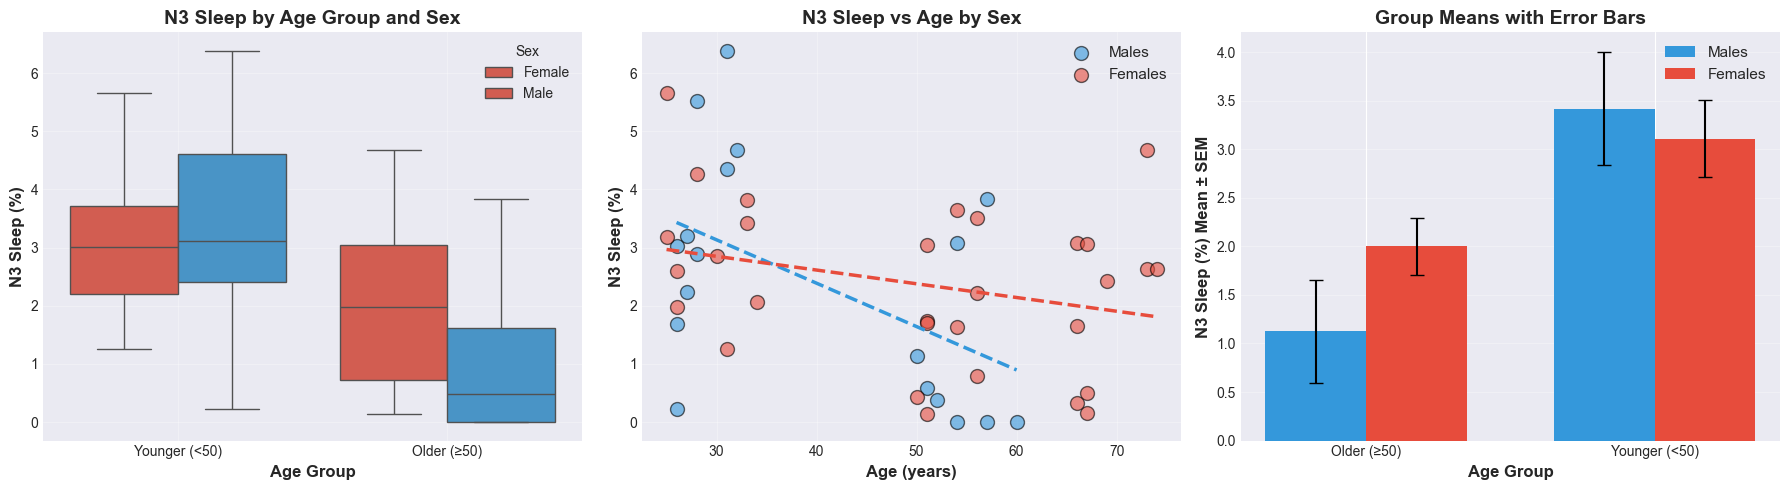

✅ Plots saved to figures/age_sex_n3_analysis.png


In [14]:
# Create comprehensive visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Box plot by Age Group and Sex
ax1 = axes[0]
sns.boxplot(data=df, x='age_group', y='n3_percent', hue='sex', ax=ax1, 
            palette={'M': '#3498db', 'F': '#e74c3c'})
ax1.set_xlabel('Age Group', fontsize=12, fontweight='bold')
ax1.set_ylabel('N3 Sleep (%)', fontsize=12, fontweight='bold')
ax1.set_title('N3 Sleep by Age Group and Sex', fontsize=14, fontweight='bold')
ax1.legend(title='Sex', labels=['Female', 'Male'])
ax1.grid(True, alpha=0.3)

# Plot 2: Scatter plot with separate regression lines
ax2 = axes[1]
for sex, color, label in [('M', '#3498db', 'Males'), ('F', '#e74c3c', 'Females')]:
    subset = df[df['sex'] == sex]
    ax2.scatter(subset['age'], subset['n3_percent'], 
                c=color, s=100, alpha=0.6, label=label, edgecolors='black')
    
    # Add regression line
    z = np.polyfit(subset['age'], subset['n3_percent'], 1)
    p = np.poly1d(z)
    ages_sorted = np.sort(subset['age'])
    ax2.plot(ages_sorted, p(ages_sorted), color=color, linewidth=2.5, linestyle='--')

ax2.set_xlabel('Age (years)', fontsize=12, fontweight='bold')
ax2.set_ylabel('N3 Sleep (%)', fontsize=12, fontweight='bold')
ax2.set_title('N3 Sleep vs Age by Sex', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# Plot 3: Mean ± SEM by group
ax3 = axes[2]
means = df.groupby(['age_group', 'sex'])['n3_percent'].mean().unstack()
sems = df.groupby(['age_group', 'sex'])['n3_percent'].sem().unstack()

x = np.arange(len(means.index))
width = 0.35

bars1 = ax3.bar(x - width/2, means['M'], width, label='Males', 
                color='#3498db', yerr=sems['M'], capsize=5)
bars2 = ax3.bar(x + width/2, means['F'], width, label='Females', 
                color='#e74c3c', yerr=sems['F'], capsize=5)

ax3.set_xlabel('Age Group', fontsize=12, fontweight='bold')
ax3.set_ylabel('N3 Sleep (%) Mean ± SEM', fontsize=12, fontweight='bold')
ax3.set_title('Group Means with Error Bars', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(means.index)
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../figures/age_sex_n3_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Plots saved to figures/age_sex_n3_analysis.png")